# Drone altitude control optimization

- Find controller gains that keep a drone near its target altitude and help it recover after a disturbance.
- Concept: [Particle swarm optimization](04-1_particle_swarm_optimization_concept.ipynb)


## Decision variables and objective

- The target altitude is 2.5 m. The controller reacts to altitude error and damps vertical motion.
- The decision variables are the proportional gain Kp and derivative gain Kd.
- PSO simulates candidate gain pairs and compares the following cost. Lower cost is better.

> Cost = altitude error penalty + control effort penalty + ground contact penalty

- The altitude error penalty accounts for deviations during the flight and at its end.
- The control effort penalty discourages excessive control input.
- The ground contact penalty applies if the drone reaches the ground-contact threshold.
- Every candidate uses the same initial altitude, velocity, and disturbance. The model includes only vertical motion.


## Drone motion and particle search

- The gray drone uses the best initial gains; the teal drone uses the global best gains found so far.
- The search space contains pairs of Kp and Kd values. Each point is one particle, representing one gain pair.
- Gray points show the previous iteration; teal points show the current iteration. Thin lines connect each particle's previous and current positions.
- The star marks gbest, which supplies the gains used by the teal drone.
- After each flight, the next iteration updates both the particles and the controller gains. Swarm convergence does not guarantee a global optimum.


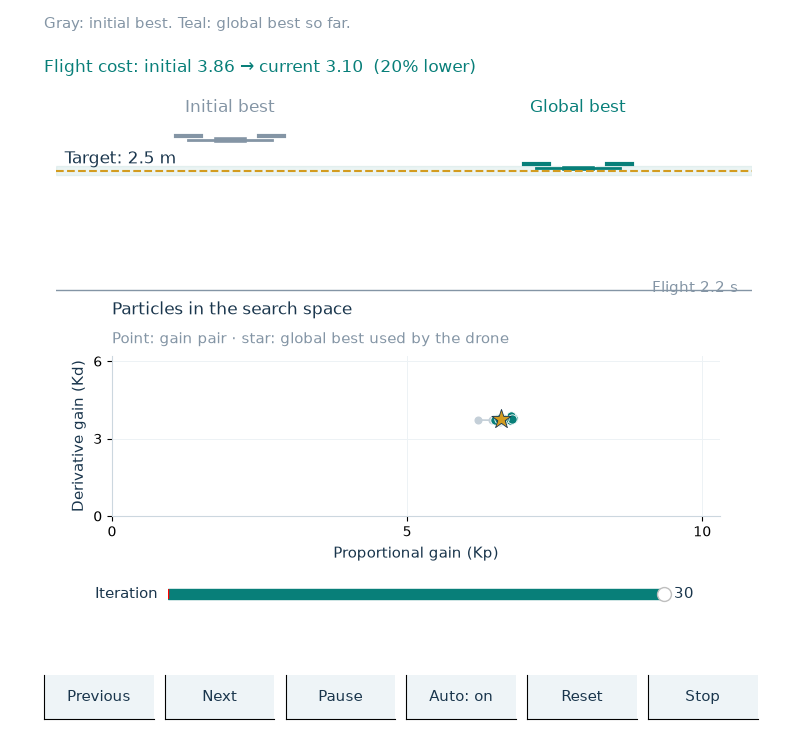

In [1]:
import os
import sys
import time
import base64
from pathlib import Path
from tempfile import gettempdir
import numpy as np
import matplotlib

STATIC = os.environ.get('OPTIMIZATION_STATIC') == '1'
BROWSER = sys.platform == 'emscripten'
INLINE_HTML = bool(globals().pop('_optimization_inline_html', False))
if not STATIC and not BROWSER and not INLINE_HTML:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, 'kernel', None) is not None:
        shell.run_line_magic('matplotlib', 'widget')

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle, Circle

# A subset of DejaVu Sans is bundled for consistent offline rendering.
FONT_DATA = '...'
_font_path = Path(gettempdir()) / 'optimization-lecture-font.ttf'
_font_bytes = base64.b64decode(FONT_DATA)
if not _font_path.exists() or _font_path.read_bytes() != _font_bytes:
    _font_path.write_bytes(_font_bytes)
font_manager.fontManager.addfont(str(_font_path))
_font_name = font_manager.FontProperties(fname=str(_font_path)).get_name()
NAVY, TEAL, GRAY = '#19354c', '#087f79', '#8495a5'
ORANGE, GOLD, RED = '#c56813', '#d39c20', '#bc3b50'
PALE = '#eef4f7'
plt.rcParams.update({
    'font.family': _font_name, 'font.size': 11, 'axes.titlesize': 12,
    'axes.titleweight': 'normal', 'axes.unicode_minus': False,
    'text.color': NAVY, 'axes.labelcolor': NAVY, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 100,
})


class LiveView:
    """A motion comparison, one progress curve, and a small set of controls."""

    def __init__(self, subtitle, duration, last_stage, stage_label='Iteration', step_size=False):
        self.figure = plt.figure(figsize=(8, 6.6))
        self.figure.text(.055, .895, subtitle, fontsize=11, color=GRAY)
        self.status = self.figure.text(.055, .840, '', fontsize=12, color=TEAL)
        self.scene = self.figure.add_axes([.07, .465, .87, .34])
        self.progress = self.figure.add_axes([.12, .268, .79, .12])
        self.controls, self.state = {}, {}
        self.duration, self.elapsed = float(duration), 0.
        self.playing, self.automatic, self.running = True, True, False
        self.timer = None
        self.last_tick = time.monotonic()
        self.render = lambda t: None
        self.redraw = lambda: None
        self.last_stage = int(last_stage)
        self.stage_label = stage_label
        self.figure.canvas.mpl_connect('close_event', lambda event: self.stop())
        self.add_slider('stage', stage_label, 0, last_stage, 0, 1, [.21, .175, .62, .025], '%0.0f')
        if step_size:
            self.add_slider('alpha', 'Step size', .05, 2.3, .35, .05, [.21, .120, .62, .025], '%0.2f')
        actions = [('back', 'Previous', lambda _: self.manual_step(-1)),
                   ('next', 'Next', lambda _: self.manual_step(1)),
                   ('play', 'Pause', self.toggle_play),
                   ('auto', 'Auto: on', self.toggle_auto),
                   ('reset', 'Reset', lambda _: self.reset_all()),
                   ('stop', 'Stop', lambda _: self.stop())]
        for i, (name, label, callback) in enumerate(actions):
            button = Button(self.figure.add_axes([.055 + .151*i, .031, .137, .055]), label,
                            color=PALE, hovercolor='#d4e8e4')
            button.label.set_fontsize(10.5)
            button.on_clicked(callback)
            self.controls[name] = button
        self.controls['stage'].on_changed(self.choose_stage)
        if step_size:
            self.controls['alpha'].on_changed(self.change_step_size)
        self.figure._live_view = self

    def compact_header(self):
        width, height = self.figure.get_size_inches()
        new_height = height - .56
        scale = height / new_height
        for ax in self.figure.axes:
            x, y, w, h = ax.get_position().bounds
            ax.set_position([x, y*scale, w, h*scale])
        for text in self.figure.texts:
            x, y = text.get_position()
            text.set_position((x, y*scale))
        self.figure.set_size_inches(width, new_height)

    def add_slider(self, name, label, low, high, initial, step, rect, valfmt):
        slider = Slider(self.figure.add_axes(rect), label, low, high, valinit=initial,
                        valstep=step, valfmt=valfmt, color=TEAL)
        slider.label.set_fontsize(11)
        slider.valtext.set_fontsize(11)
        self.controls[name] = slider

    def values(self, **values):
        for name, value in values.items():
            slider = self.controls[name]
            old_events, old_draw = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = old_events, old_draw

    def sync(self):
        self.controls['play'].label.set_text('Pause' if self.playing else 'Play')
        self.controls['auto'].label.set_text('Auto: on' if self.automatic else 'Auto: off')
        self.figure.canvas.draw_idle()

    def choose_stage(self, _):
        self.automatic = False
        self.redraw()
        self.sync()

    def change_step_size(self, _):
        self.values(stage=0)
        self.automatic, self.playing = True, True
        self.redraw()
        self.sync()

    def advance(self, direction):
        old = int(self.controls['stage'].val)
        new = int(np.clip(old + direction, 0, self.last_stage))
        if old == new:
            return False
        self.values(stage=new)
        self.redraw()
        return True

    def manual_step(self, direction):
        self.automatic = False
        self.advance(direction)
        self.sync()

    def clear(self):
        self.scene.clear()
        self.progress.clear()

    def history(self, values, title, last_stage):
        values = np.asarray(values, dtype=float)
        ax = self.progress
        ax.plot(np.arange(len(values)), values, color=TEAL, lw=2.5)
        ax.plot(len(values)-1, values[-1], 'o', color=TEAL, ms=6)
        ax.axhline(values[0], color=GRAY, ls='--', lw=1, alpha=.7)
        ax.set_title(title, loc='left', pad=9)
        ax.set_xlim(-.5, last_stage+.5)
        top = max(1e-3, float(values.max()))
        ax.set_ylim(0, top*1.25)
        ax.set_xticks([0, last_stage])
        ax.set_yticks([0, top])
        ax.set_yticklabels(['0', f'{top:.2g}'])
        ax.tick_params(labelsize=10)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#ccd7df')

    def set_motion(self, render):
        self.render = render
        self.elapsed = 0.
        self.last_tick = time.monotonic()
        self.frame(0.)

    def frame(self, seconds):
        self.render(float(np.clip(seconds, 0, self.duration)))
        self.figure.canvas.draw_idle()

    def toggle_play(self, _=None):
        if not self.playing and self.elapsed >= self.duration:
            self.elapsed = 0.
        self.playing = not self.playing
        self.last_tick = time.monotonic()
        self.sync()

    def toggle_auto(self, _=None):
        self.automatic = not self.automatic
        if self.automatic:
            if self.elapsed >= self.duration:
                self.elapsed = 0.
            self.playing = True
        self.last_tick = time.monotonic()
        self.sync()

    def reset_all(self):
        self.automatic, self.playing = True, True
        self.values(stage=0, **({'alpha': .35} if 'alpha' in self.controls else {}))
        self.redraw()
        self.sync()

    def tick(self, now=None):
        now = time.monotonic() if now is None else now
        delta = max(0., now-self.last_tick)
        self.last_tick = now
        if not self.running or not self.playing:
            return
        self.elapsed += delta
        if self.elapsed > self.duration+.7:
            if self.automatic and self.advance(1):
                self.elapsed = 0.
            else:
                self.elapsed = self.duration
                self.playing = self.automatic = False
                self.sync()
        self.frame(self.elapsed)

    def start(self):
        if STATIC:
            self.values(stage=self.last_stage)
            self.redraw()
            self.elapsed = getattr(self, 'preview_time', .7*self.duration)
            self.frame(self.elapsed)
            from io import BytesIO
            from IPython.display import Image, display
            preview = BytesIO()
            self.figure.savefig(preview, format='png', dpi=100, bbox_inches=None)
            display(Image(data=preview.getvalue(), width=800))
            plt.close(self.figure)
            return
        self.running = True
        self.last_tick = time.monotonic()
        self.controls['stop'].label.set_text('Stop')
        if BROWSER:
            plt.show()
            try:
                while self.running and plt.fignum_exists(self.figure.number):
                    self.tick()
                    plt.pause(1/30)
            finally:
                self.stop()
        else:
            if self.timer is not None:
                self.timer.stop()
            self.timer = self.figure.canvas.new_timer(interval=33)
            self.timer.add_callback(self.tick)
            self.timer.start()
            plt.show()

    def stop(self):
        self.running = self.playing = False
        if self.timer is not None:
            self.timer.stop()
        self.controls['stop'].label.set_text('Stopped')
        self.sync()

    def close(self):
        self.stop()
        plt.close(self.figure)


DRONE_DT = .025
DRONE_DURATION = 6.
TARGET_HEIGHT = 2.5
GAIN_LOW = np.array([.2, .1])
GAIN_HIGH = np.array([10., 6.])
PSO_STEPS = 30
PARTICLES = 16


def simulate_drones(parameters):
    """Net vertical acceleration after gravity compensation, with a fixed gust."""
    parameters = np.atleast_2d(np.asarray(parameters, dtype=float))
    n = round(DRONE_DURATION / DRONE_DT)
    times = np.arange(n + 1) * DRONE_DT
    height = np.empty((n + 1, len(parameters)))
    velocity = np.zeros_like(height)
    effort = np.empty((n, len(parameters)))
    cost = np.zeros_like(height)
    contact = np.zeros_like(height, dtype=bool)
    height[0] = .3
    for k in range(n):
        effort[k] = np.clip(parameters[:, 0] * (TARGET_HEIGHT - height[k])
                            - parameters[:, 1] * velocity[k], -4, 4)
        effort[k, contact[k]] = 0.
        gust = -1.5 if 2.5 <= times[k] < 3.0 else 0.
        velocity[k + 1] = velocity[k] + DRONE_DT * (effort[k] + gust)
        height[k + 1] = height[k] + DRONE_DT * velocity[k + 1]
        contact[k + 1] = contact[k] | (height[k + 1] <= .15)
        height[k + 1, contact[k + 1]] = .15
        velocity[k + 1, contact[k + 1]] = 0.
        cost[k + 1] = cost[k] + DRONE_DT * (
            (height[k + 1] - TARGET_HEIGHT) ** 2 + .025 * effort[k] ** 2)
    loss = cost[-1] + 2 * (height[-1] - TARGET_HEIGHT) ** 2 + 20 * contact[-1]
    return dict(t=times, height=height, velocity=velocity, effort=effort,
                cost=cost, loss=loss, contact=contact)


def drone_loss(parameters):
    return simulate_drones(parameters)["loss"]


def run_pso(seed=11, inertia=.65, personal=1.6, social=1.6, steps=PSO_STEPS):
    rng = np.random.default_rng(seed)
    # An initially weak controller population, not an injected optimal controller.
    position = rng.uniform(GAIN_LOW, [2., 1.5], (PARTICLES, 2))
    velocity = rng.uniform(-.5, .5, (PARTICLES, 2))
    pbest = position.copy()
    pscore = drone_loss(pbest)
    gbest = pbest[np.argmin(pscore)].copy()
    states, transitions = [], []

    def remember():
        states.append(dict(position=position.copy(), velocity=velocity.copy(),
                           pbest=pbest.copy(), pscore=pscore.copy(),
                           score=drone_loss(position), gbest=gbest.copy(),
                           gscore=float(pscore.min())))

    remember()
    for _ in range(steps):
        r1, r2 = rng.random((PARTICLES, 2)), rng.random((PARTICLES, 2))
        momentum = inertia * velocity
        own_pull = personal * r1 * (pbest - position)
        group_pull = social * r2 * (gbest - position)
        raw = momentum + own_pull + group_pull
        limited = np.clip(raw, [-1.5, -.9], [1.5, .9])
        proposed = position + limited
        updated = np.clip(proposed, GAIN_LOW, GAIN_HIGH)
        transitions.append(dict(momentum=momentum.copy(), own_pull=own_pull.copy(),
                                group_pull=group_pull.copy(), raw_velocity=raw.copy(),
                                displacement=updated - position, r1=r1, r2=r2))
        velocity = np.where(updated == proposed, limited, 0.)
        position = updated
        score = drone_loss(position)
        improved = score < pscore
        pbest[improved], pscore[improved] = position[improved], score[improved]
        gbest = pbest[np.argmin(pscore)].copy()
        remember()
    return dict(states=states, transitions=transitions)


def show_pso_explorer():
    view = LiveView('Gray: initial best. Teal: global best so far.', DRONE_DURATION, PSO_STEPS)
    view.figure.set_size_inches(8, 8)
    view.scene.set_position([.07, .555, .87, .25])
    view.progress.set_position([.14, .285, .76, .20])
    view.compact_header()
    history = run_pso(seed=11)
    def redraw():
        k = int(view.controls['stage'].val)
        parameters = np.array([history['states'][0]['gbest'], history['states'][k]['gbest']])
        trial = simulate_drones(parameters)
        scores = np.array([s['gscore'] for s in history['states']])
        improvement = 100*(1-scores[k]/scores[0]) if scores[0] else 0.
        view.state.update(history=history, stage=k, trial=trial, parameters=parameters)
        view.clear()
        view.status.set_text(f'Flight cost: initial {scores[0]:.2f} → current {scores[k]:.2f}  ({improvement:.0f}% lower)')
        ax = view.scene
        top = max(3.8, float(trial['height'].max())+.8)
        ax.set(xlim=(0, 8), ylim=(-.2, top))
        ax.axis('off')
        ax.axhline(0, color=GRAY, lw=1)
        ax.axhspan(TARGET_HEIGHT-.10, TARGET_HEIGHT+.10, color=TEAL, alpha=.08)
        ax.axhline(TARGET_HEIGHT, color=GOLD, ls='--', lw=1.5)
        ax.text(.1, TARGET_HEIGHT+.15, 'Target: 2.5 m', fontsize=12)
        centers = [2., 6.]
        bodies, arms, rotors = [], [], []
        for center, color, label in zip(centers, [GRAY, TEAL], ['Initial best', 'Global best']):
            ax.text(center, top-.25, label, ha='center', color=color, fontsize=12)
            body = Rectangle((center-.20, .3), .4, .14, fc=color, ec='white')
            ax.add_patch(body)
            arm, = ax.plot([], [], color=color, lw=2)
            rotor, = ax.plot([], [], color=color, lw=3)
            bodies.append(body); arms.append(arm); rotors.append(rotor)
        gust = ax.text(4, top*.52, '', ha='center', color=RED, fontsize=12)
        clock = ax.text(.98, .04, '', ha='right', transform=ax.transAxes, color=GRAY, fontsize=11)
        space = view.progress
        state = history['states'][k]
        position = state['position']
        previous = history['states'][max(0, k-1)]['position']
        space.set(xlim=(0, GAIN_HIGH[0]+.3), ylim=(0, GAIN_HIGH[1]+.2))
        space.set_title('Particles in the search space', loc='left', pad=30, fontsize=12)
        space.text(0, 1.08, 'Point: gain pair · star: global best used by the drone',
                   transform=space.transAxes, fontsize=10.5, color=GRAY)
        space.plot(np.array([previous[:, 0], position[:, 0]]),
                   np.array([previous[:, 1], position[:, 1]]), color='#b8c6d0', lw=1, zorder=1)
        space.scatter(previous[:, 0], previous[:, 1], s=23, c='#c4cfd8', zorder=2)
        particles = space.scatter(position[:, 0], position[:, 1], s=45, c=TEAL,
                                  edgecolors='white', linewidths=.6, zorder=3)
        best_marker = space.scatter(*state['gbest'], marker='*', s=210, c=GOLD,
                                    edgecolors=NAVY, linewidths=.6, zorder=4)
        space.set_xlabel('Proportional gain (Kp)', fontsize=10.5, labelpad=5)
        space.set_ylabel('Derivative gain (Kd)', fontsize=10.5, labelpad=5)
        space.set_xticks([0, 5, 10]); space.set_yticks([0, 3, 6])
        space.tick_params(labelsize=10)
        space.grid(color='#edf2f5', lw=.7)
        space.spines[['top', 'right']].set_visible(False)
        space.spines[['left', 'bottom']].set_color('#ccd7df')
        view.state.update(particles=particles, best_marker=best_marker, previous_position=previous.copy())
        def frame(t):
            for j, center in enumerate(centers):
                height = np.interp(t, trial['t'], trial['height'][:, j])
                bodies[j].set_y(height-.07)
                arms[j].set_data([center-.48, center+.48], [height, height])
                rotors[j].set_data([center-.62, center-.33, np.nan, center+.33, center+.62],
                                   [height+.08]*5)
            gust.set_text('↓ Disturbance' if 2.5 <= t < 3 else '')
            clock.set_text(f'Flight {t:.1f} s')
        view.preview_time = 2.2
        view.set_motion(frame)
    view.redraw = redraw
    redraw()
    return view


if 'pso_demo' in globals() and hasattr(pso_demo, 'close'):
    pso_demo.close()
pso_demo = show_pso_explorer()
pso_demo.start()
